# Module 3 — Insurance & Financial Layer: Charts

Descriptive Python charts for the Module 3 insurance figures in [`policy_and_reinsurance_structure.md`](policy_and_reinsurance_structure.md).

**Scope note:** these are descriptive charts of real, publicly disclosed market-level figures
(Nepal Insurance Authority, NEPSE, government/multilateral loss estimates) — not a stochastic
actuarial or reinsurance pricing model. Resolution matches what's publicly available; nothing
here is simulated or extrapolated beyond the source figures. See [`../data/sources.md`](../data/sources.md).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110


## Parameters

Named inputs only. Charts below read from these names. Sources: NIA May 2026 hydropower report
(multi-year market stats) and end-Aug 2026 event snapshots in [`policy_and_reinsurance_structure.md`](policy_and_reinsurance_structure.md).


In [2]:
# NIA hydropower market (May 2026 report; multi-year, not this event)
TAT_CAR_DAYS = 298
TAT_EAR_DAYS = 372
TAT_SURVEY_SHARE_LOW = 0.62
TAT_SURVEY_SHARE_HIGH = 0.75
COMBINED_RATIO_GROSS = 1.46
COMBINED_RATIO_NET = 1.08
EXPENSE_RATIO_ASSUMED = 0.05  # NIA assumption, not computed here

# This event — end-Aug 2026 snapshot, filed claims, national totals
INSURED_CLAIMS_USD_BN = 0.171  # NPR 25.87bn, 583 claims
GOVT_TOTAL_LOSS_USD_BN = 2.6
RECONSTRUCTION_NEED_LOW_USD_BN = 4.0
RECONSTRUCTION_NEED_HIGH_USD_BN = 5.0

claims_vs_loss = INSURED_CLAIMS_USD_BN / GOVT_TOTAL_LOSS_USD_BN
recon_mid = 0.5 * (RECONSTRUCTION_NEED_LOW_USD_BN + RECONSTRUCTION_NEED_HIGH_USD_BN)
claims_vs_recon = INSURED_CLAIMS_USD_BN / recon_mid
implied_gross_loss_ratio = COMBINED_RATIO_GROSS - EXPENSE_RATIO_ASSUMED
implied_net_loss_ratio = COMBINED_RATIO_NET - EXPENSE_RATIO_ASSUMED

print(f"Filed claims / national loss = {100 * claims_vs_loss:.1f}%")
print(f"Filed claims / reconstruction midpoint = {100 * claims_vs_recon:.1f}%")
print(f"Reconstruction band = ${RECONSTRUCTION_NEED_LOW_USD_BN:.0f}–{RECONSTRUCTION_NEED_HIGH_USD_BN:.0f}B (mid ${recon_mid:.1f}B)")
print(f"Implied gross loss ratio ≈ {100 * implied_gross_loss_ratio:.0f}%  (combined {100 * COMBINED_RATIO_GROSS:.0f}% minus {100 * EXPENSE_RATIO_ASSUMED:.0f}% expense)")
print(f"Implied net loss ratio ≈ {100 * implied_net_loss_ratio:.0f}%")


Filed claims / national loss = 6.6%
Filed claims / reconstruction midpoint = 3.8%
Reconstruction band = $4–5B (mid $4.5B)
Implied gross loss ratio ≈ 141%  (combined 146% minus 5% expense)
Implied net loss ratio ≈ 103%


## Claims settlement time-to-close, by policy type

Source: Nepal Insurance Authority, "Hydropower Insurance in Nepal" (May 2026), n = 121 paid claims.


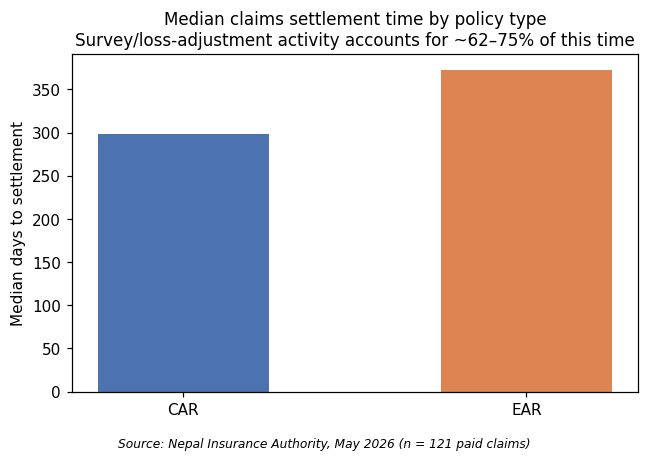

In [3]:
tat = pd.DataFrame({
    "policy_type": ["CAR", "EAR"],
    "median_days": [TAT_CAR_DAYS, TAT_EAR_DAYS],
})

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(tat["policy_type"], tat["median_days"], width=0.5, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Median days to settlement")
ax.set_title(
    "Median claims settlement time by policy type\n"
    f"Survey/loss-adjustment activity accounts for "
    f"~{100 * TAT_SURVEY_SHARE_LOW:.0f}–{100 * TAT_SURVEY_SHARE_HIGH:.0f}% of this time",
    fontsize=11,
)
fig.text(
    0.5, -0.03,
    "Source: Nepal Insurance Authority, May 2026 (n = 121 paid claims)",
    ha="center", fontsize=8, style="italic",
)
plt.tight_layout()
plt.savefig("claims_settlement_time.png", dpi=150, bbox_inches="tight")
plt.show()


## Combined ratio

NIA five-year average (excludes an early year with incomplete pre-MTR data and the most
recent partial year); assumes a 5% expense ratio.


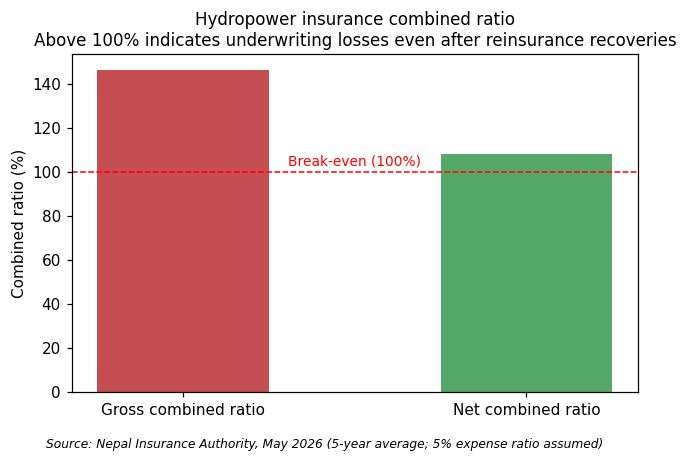

In [4]:
combined_ratio = pd.DataFrame({
    "measure": ["Gross combined ratio", "Net combined ratio"],
    "value_pct": [100 * COMBINED_RATIO_GROSS, 100 * COMBINED_RATIO_NET],
})

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(combined_ratio["measure"], combined_ratio["value_pct"], width=0.5, color=["#C44E52", "#55A868"])
ax.axhline(100, color="red", linestyle="--", linewidth=1)
ax.text(0.5, 103, "Break-even (100%)", color="red", fontsize=9, ha="center")
ax.set_ylabel("Combined ratio (%)")
ax.set_title(
    "Hydropower insurance combined ratio\n"
    "Above 100% indicates underwriting losses even after reinsurance recoveries",
    fontsize=11,
)
fig.text(
    0.5, -0.03,
    "Source: Nepal Insurance Authority, May 2026 (5-year average; 5% expense ratio assumed)",
    ha="center", fontsize=8, style="italic",
)
plt.tight_layout()
plt.savefig("combined_ratio.png", dpi=150, bbox_inches="tight")
plt.show()


## Protection gap

Insured claims *filed* (end-Aug 2026) vs. government-estimated total direct national loss vs.
estimated reconstruction need ($4–5B; bar uses the midpoint).

Filed ≠ paid. Industry claims are commercial/hydropower-heavy. All three figures are sourced
(see [`../data/sources.md`](../data/sources.md)) — none are synthetic.


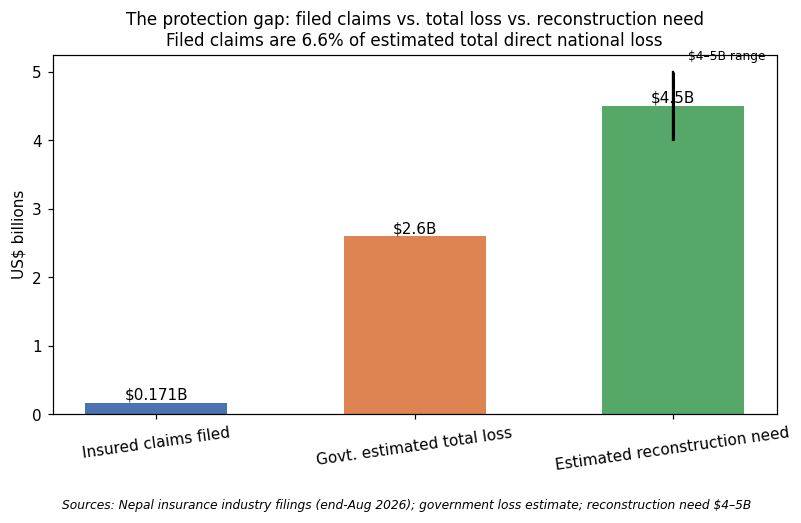

In [5]:
protection_gap = pd.DataFrame({
    "category": [
        "Insured claims filed",
        "Govt. estimated total loss",
        "Estimated reconstruction need",
    ],
    "usd_billions": [INSURED_CLAIMS_USD_BN, GOVT_TOTAL_LOSS_USD_BN, recon_mid],
})

fig, ax = plt.subplots(figsize=(7.5, 4.5))
colors = ["#4C72B0", "#DD8452", "#55A868"]
bars = ax.bar(protection_gap["category"], protection_gap["usd_billions"], width=0.55, color=colors)

for bar, val in zip(bars, protection_gap["usd_billions"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
        f"${val}B", ha="center", fontsize=10,
    )

# 4–5 band on the reconstruction bar only
recon_bar = bars[2]
x = recon_bar.get_x() + recon_bar.get_width() / 2
ax.vlines(
    x,
    RECONSTRUCTION_NEED_LOW_USD_BN,
    RECONSTRUCTION_NEED_HIGH_USD_BN,
    color="black",
    linewidth=2,
)
ax.plot(
    [x, x],
    [RECONSTRUCTION_NEED_LOW_USD_BN, RECONSTRUCTION_NEED_HIGH_USD_BN],
    color="black",
)
ax.annotate(
    "$4–5B range",
    xy=(x, RECONSTRUCTION_NEED_HIGH_USD_BN),
    xytext=(10, 8),
    textcoords="offset points",
    fontsize=8,
)

ax.set_ylabel("US$ billions")
ax.set_title(
    "The protection gap: filed claims vs. total loss vs. reconstruction need\n"
    f"Filed claims are {100 * claims_vs_loss:.1f}% of estimated total direct national loss",
    fontsize=11,
)
fig.text(
    0.5, -0.04,
    "Sources: Nepal insurance industry filings (end-Aug 2026); government loss estimate; reconstruction need $4–5B",
    ha="center", fontsize=8, style="italic",
)
plt.xticks(rotation=8)
plt.tight_layout()
plt.savefig("protection_gap.png", dpi=150, bbox_inches="tight")
plt.show()
